Merge và Join các file lại với nhau.

**Các bảng mới được tạo ra là:**
1. order_detail
(orders.csv, customers.csv, shipments.csv, payments.csv, geography.csv)

2. orders_sales
(sales.csv, orders.csv)

3. order_traffic
(web_traffic.csv, orders.csv)

4. inventory_detail
(inventory.csv, products.csv)

5. returns_detail
(products.csv, orders.csv, returns.csv)

6. fact_table
(products.csv, orders.csv, promotions.csv, order_items.csv)

# Mục mới

In [ ]:
import pandas as pd

# Đọc tất cả các file CSV
customers = pd.read_csv('customers.csv')
orders = pd.read_csv('orders.csv')
shipments = pd.read_csv('shipments.csv')
payments = pd.read_csv('payments.csv')
geography = pd.read_csv('geography.csv')
order_items = pd.read_csv('order_items.csv', low_memory=False)  # Fix warning
products = pd.read_csv('products.csv')
promotions = pd.read_csv('promotions.csv')
returns = pd.read_csv('returns.csv')
reviews = pd.read_csv('reviews.csv')
sales = pd.read_csv('sales.csv')
web_traffic = pd.read_csv('web_traffic.csv')

print("✅ Đã đọc xong tất cả các file!")
print(f"Customers: {len(customers):,} dòng")
print(f"Orders: {len(orders):,} dòng")
print(f"Order items: {len(order_items):,} dòng")
print(f"Products: {len(products):,} dòng")
print(f"Shipments: {len(shipments):,} dòng")
print(f"Payments: {len(payments):,} dòng")

# ==================== JOIN THEO SƠ ĐỒ ====================

# Bước 1: Customers + Geography (địa chỉ nơi ở của khách hàng)
customers_geo = customers.merge(
    geography,
    on='zip',
    how='left',
    suffixes=('', '_home')  # Địa chỉ nhà
)

print(f"\n✅ Bước 1: Customers + Geography = {len(customers_geo):,} dòng")

# Bước 2: Orders + Customers (kèm địa chỉ nhà)
orders_customers = orders.merge(
    customers_geo,
    on='customer_id',
    how='left',
    suffixes=('_order', '_customer')
)

print(f"✅ Bước 2: Orders + Customers = {len(orders_customers):,} dòng")

# Bước 3: Thêm Geography cho địa chỉ GIAO HÀNG (từ orders.zip)
orders_full = orders_customers.merge(
    geography,
    left_on='zip_order',
    right_on='zip',
    how='left',
    suffixes=('', '_delivery')
)

print(f"✅ Bước 3: + Geography (giao hàng) = {len(orders_full):,} dòng")

# Bước 4: Orders + Shipments
orders_shipments = orders_full.merge(
    shipments,
    on='order_id',
    how='left'
)

print(f"✅ Bước 4: + Shipments = {len(orders_shipments):,} dòng")

# Bước 5: Orders + Payments
orders_main = orders_shipments.merge(
    payments,
    on='order_id',
    how='left',
    suffixes=('', '_pay')
)

print(f"✅ Bước 5: + Payments = {len(orders_main):,} dòng")

# Bước 6: Orders + Order_items (1:nhiều)
orders_items = orders_main.merge(
    order_items,
    on='order_id',
    how='left'
)

print(f"✅ Bước 6: + Order_items = {len(orders_items):,} dòng")

# Bước 7: Order_items + Products
orders_products = orders_items.merge(
    products,
    on='product_id',
    how='left',
    suffixes=('', '_prod')
)

print(f"✅ Bước 7: + Products = {len(orders_products):,} dòng")

# Bước 8: + Promotions lần 1
orders_promo = orders_products.merge(
    promotions,
    left_on='promo_id',
    right_on='promo_id',
    how='left',
    suffixes=('', '_promo1')
)

print(f"✅ Bước 8: + Promotions 1 = {len(orders_promo):,} dòng")

# Bước 9: + Promotions lần 2 -> Đặt tên là order_detail
order_detail = orders_promo.merge(
    promotions,
    left_on='promo_id_2',
    right_on='promo_id',
    how='left',
    suffixes=('_promo1', '_promo2')
)

print(f"\n🎉 ĐÃ JOIN XONG!")
print(f"📊 Bảng order_detail: {len(order_detail):,} dòng x {len(order_detail.columns)} cột")

# Xem preview
print("\n📋 Preview 3 dòng đầu của order_detail:")
display(order_detail.head(3))

✅ Đã đọc xong tất cả các file!
Customers: 121,930 dòng
Orders: 646,945 dòng
Order items: 714,669 dòng
Products: 2,412 dòng
Shipments: 566,067 dòng
Payments: 646,945 dòng

✅ Bước 1: Customers + Geography = 121,930 dòng
✅ Bước 2: Orders + Customers = 646,945 dòng
✅ Bước 3: + Geography (giao hàng) = 646,945 dòng
✅ Bước 4: + Shipments = 646,945 dòng
✅ Bước 5: + Payments = 646,945 dòng
✅ Bước 6: + Order_items = 714,669 dòng
✅ Bước 7: + Products = 714,669 dòng
✅ Bước 8: + Promotions 1 = 714,669 dòng

🎉 ĐÃ JOIN XONG!
📊 Bảng order_detail: 714,669 dòng x 59 cột

📋 Preview 3 dòng đầu của order_detail:


,order_id,order_date,customer_id,zip_order,order_status,payment_method,device_type,order_source,zip_customer,city,...,promo_id_promo2,promo_name_promo2,promo_type_promo2,discount_value_promo2,start_date_promo2,end_date_promo2,applicable_category_promo2,promo_channel_promo2,stackable_flag_promo2,min_order_value_promo2
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,1109,Hanoi,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search,1330,Phu Ly,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,1473,Lao Cai,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Merge sales (bảng chính) với orders qua trường ngày tương ứng
orders_sales = sales.merge(
    orders,
    left_on='Date',
    right_on='order_date',
    how='left'
)

print(f"✅ Đã merge xong sales và orders (sales làm gốc)!")
print(f"📊 Bảng orders_sales: {len(orders_sales):,} dòng x {len(orders_sales.columns)} cột")

# Xem preview
display(orders_sales.head(3))

✅ Đã merge xong sales và orders (sales làm gốc)!
📊 Bảng orders_sales: 646,945 dòng x 11 cột


,Date,Revenue,COGS,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,2012-07-04,5123547.94,3982991.19,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2012-07-04,5123547.94,3982991.19,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,2012-07-04,5123547.94,3982991.19,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct


In [ ]:
# Merge web_traffic (bảng chính) với orders qua trường ngày tương ứng
order_traffic = web_traffic.merge(
    orders,
    left_on='date',
    right_on='order_date',
    how='left'
)

print(f"✅ Đã merge xong web_traffic và orders (web_traffic làm gốc)!")
print(f"📊 Bảng order_traffic: {len(order_traffic):,} dòng x {len(order_traffic.columns)} cột")

# Xem preview
display(order_traffic.head(3))

✅ Đã merge xong web_traffic và orders (web_traffic làm gốc)!
📊 Bảng order_traffic: 614,894 dòng x 15 cột


,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,2013-01-01,9760,7253,39093,0.00514,102.9,organic_search,39924,2013-01-01,58586,1118,delivered,apple_pay,mobile,direct
1,2013-01-01,9760,7253,39093,0.00514,102.9,organic_search,39933,2013-01-01,58822,1475,delivered,credit_card,desktop,paid_search
2,2013-01-01,9760,7253,39093,0.00514,102.9,organic_search,39938,2013-01-01,59466,2364,delivered,credit_card,desktop,organic_search


In [ ]:
import pandas as pd

# Bước 1: Đọc dữ liệu cần thiết
products = pd.read_csv('products.csv')
inventory = pd.read_csv('inventory.csv')

# Bước 2: Merge inventory (bảng chính) với products
inventory_detail = inventory.merge(
    products,
    on='product_id',
    how='left'
)

print(f"✅ Đã tạo xong bảng inventory_detail!")
print(f"📊 Quy mô: {len(inventory_detail):,} dòng x {len(inventory_detail.columns)} cột")

# Xem preview
display(inventory_detail.head(3))

✅ Đã tạo xong bảng inventory_detail!
📊 Quy mô: 60,247 dòng x 24 cột


,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,...,segment_x,year,month,product_name_y,category_y,segment_y,size,color,price,cogs
0,2022-10-31,1,3,1,1,2,90.0,0.9333,1,0,...,All-weather,2022,10,DragonWear MA-01,Casual,All-weather,M,black,4945.5,2732.8833
1,2022-11-30,1,3,1,1,1,90.0,0.9667,1,0,...,All-weather,2022,11,DragonWear MA-01,Casual,All-weather,M,black,4945.5,2732.8833
2,2022-12-31,1,3,1,1,1,90.0,0.9667,1,0,...,All-weather,2022,12,DragonWear MA-01,Casual,All-weather,M,black,4945.5,2732.8833


In [ ]:
import pandas as pd

# Bước 1: Đọc dữ liệu
returns = pd.read_csv('returns.csv')
products = pd.read_csv('products.csv')
orders = pd.read_csv('orders.csv')

# Bước 2: Merge returns (bảng chính) với products và orders
returns_detail = returns.merge(
    products,
    on='product_id',
    how='left'
).merge(
    orders,
    on='order_id',
    how='left',
    suffixes=('', '_order')
)

print(f"✅ Đã tạo xong bảng returns_detail!")
print(f"📊 Quy mô: {len(returns_detail):,} dòng x {len(returns_detail.columns)} cột")

# Xem preview
display(returns_detail.head(3))

✅ Đã tạo xong bảng returns_detail!
📊 Quy mô: 39,939 dòng x 21 cột


,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount,product_name,category,segment,...,color,price,cogs,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,RET-000001,2,609,2012-07-25,late_delivery,6,52458.01,SaigonFlex UC-74,Streetwear,Everyday,...,yellow,10426.571034,8987.704231,2012-07-04,58621,1330,returned,cod,mobile,paid_search
1,RET-000002,32,1862,2012-07-16,wrong_size,2,5141.37,SaigonCore YY-57,GenZ,Trendy,...,orange,2656.232069,1842.628186,2012-07-05,6037,17033,returned,credit_card,desktop,social_media
2,RET-000003,35,2359,2012-07-16,wrong_size,1,5315.95,VietMotion UC-07,Streetwear,Everyday,...,yellow,5399.825901,3136.758866,2012-07-04,3666,18944,returned,credit_card,desktop,organic_search


In [ ]:
import pandas as pd

# Bước 1: Đọc dữ liệu cần thiết
order_items = pd.read_csv('order_items.csv', low_memory=False)
products = pd.read_csv('products.csv')
orders = pd.read_csv('orders.csv')
promotions = pd.read_csv('promotions.csv')

# Bước 2: Merge order_items với products và orders
fact_table = order_items.merge(
    products, on='product_id', how='left'
).merge(
    orders, on='order_id', how='left'
)

# Bước 3: Merge với promotions lần 1 (cho promo_id)
fact_table = fact_table.merge(
    promotions,
    left_on='promo_id',
    right_on='promo_id',
    how='left',
    suffixes=('', '_promo1')
)

# Bước 4: Merge với promotions lần 2 (cho promo_id_2 nếu có)
# Giả sử cột thứ hai là 'promo_id_2'
if 'promo_id_2' in fact_table.columns:
    fact_table = fact_table.merge(
        promotions,
        left_on='promo_id_2',
        right_on='promo_id',
        how='left',
        suffixes=('_promo1', '_promo2')
    )

print(f"✅ Đã tạo xong bảng product_detail (fact table)!")
print(f"📊 Quy mô: {len(fact_table):,} dòng x {len(fact_table.columns)} cột")

# Xem preview
display(fact_table.head(3))

✅ Đã tạo xong bảng product_detail (fact table)!
📊 Quy mô: 714,669 dòng x 40 cột


,order_id,product_id,quantity,unit_price,discount_amount,promo_id_promo1,promo_id_2,product_name,category,segment,...,promo_id_promo2,promo_name_promo2,promo_type_promo2,discount_value_promo2,start_date_promo2,end_date_promo2,applicable_category_promo2,promo_channel_promo2,stackable_flag_promo2,min_order_value_promo2
0,1,2400,7,1138.22,0.0,NaN,NaN,VietMotion YY-09,GenZ,Trendy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,609,7,10166.25,0.0,NaN,NaN,SaigonFlex UC-74,Streetwear,Everyday,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,396,3,11220.33,0.0,NaN,NaN,SaigonFlex UM-01,Streetwear,Balanced,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Trend của Revenue từ 2012 - 2022

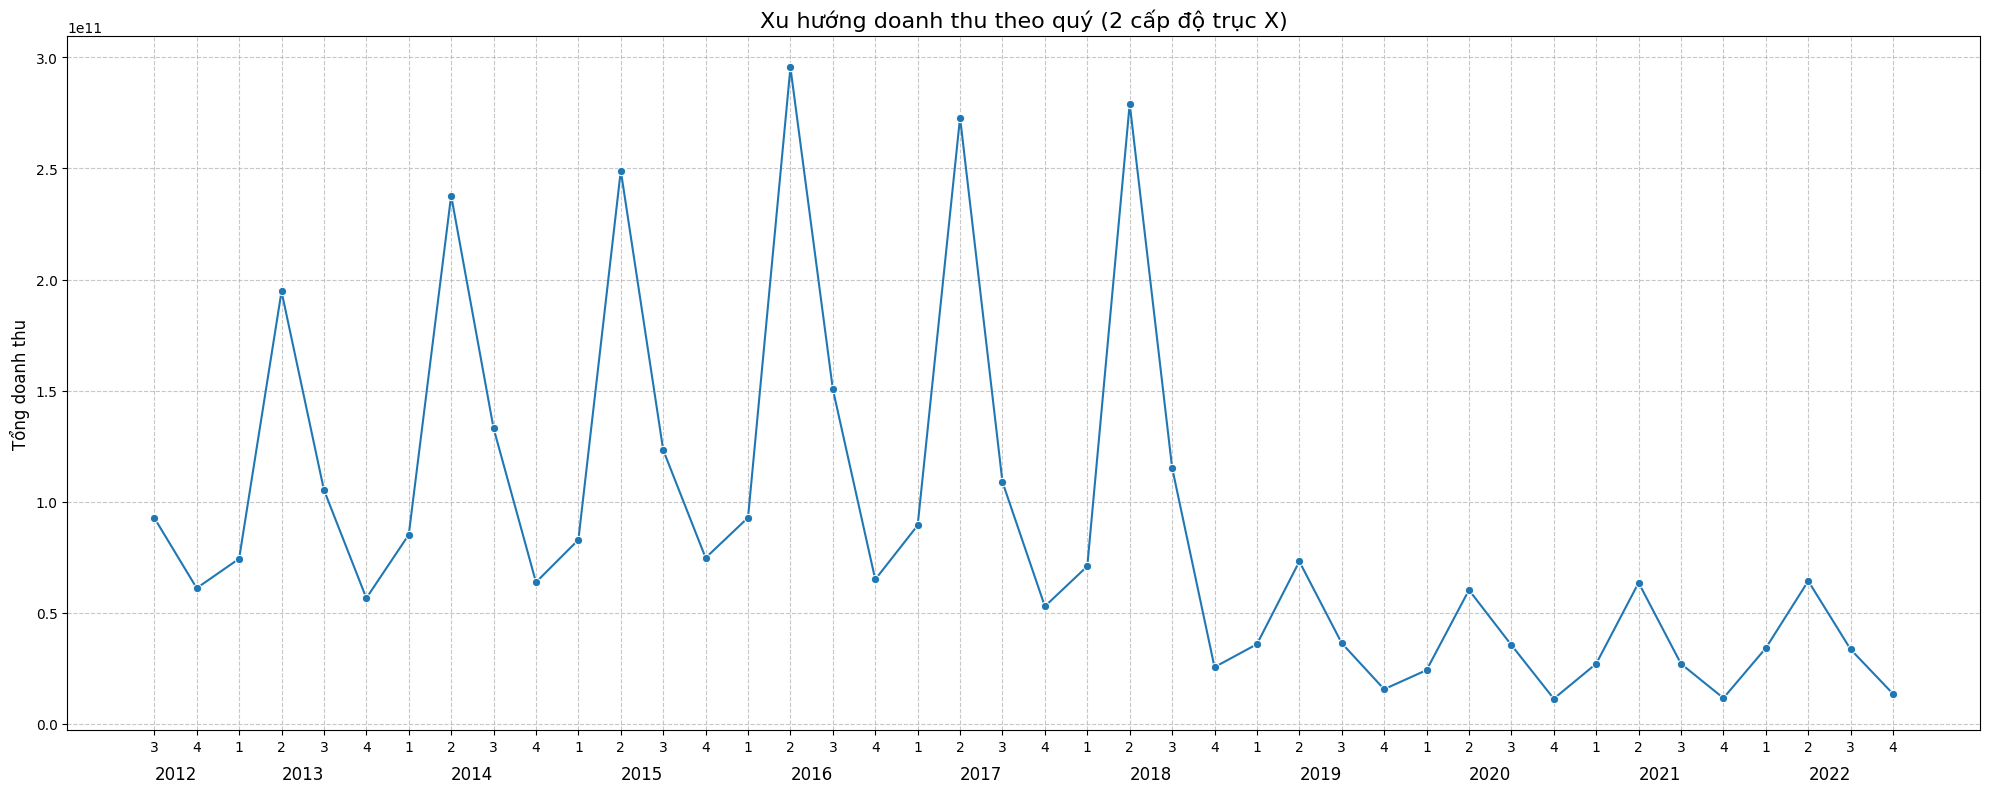

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure 'Date' is datetime and 'Quarter' is Period again for consistency
orders_sales['Date'] = pd.to_datetime(orders_sales['Date'])
orders_sales['Quarter'] = orders_sales['Date'].dt.to_period('Q')

# Recalculate quarterly_revenue
quarterly_revenue = orders_sales.groupby('Quarter')['Revenue'].sum().reset_index()

# Convert 'Quarter' to string for plotting on x-axis
quarterly_revenue['Quarter_Str'] = quarterly_revenue['Quarter'].astype(str)

# Create the plot
plt.figure(figsize=(20, 8))
line_plot = sns.lineplot(x='Quarter_Str', y='Revenue', data=quarterly_revenue, marker='o')

plt.title('Xu hướng doanh thu theo quý (2 cấp độ trục X)', fontsize=16)
plt.ylabel('Tổng doanh thu', fontsize=12)
plt.xlabel('') # Clear default x-label as we will add custom labels
plt.grid(True, linestyle='--', alpha=0.7)

# --- Custom X-axis Labels ---

# Get all unique years in the data
years = sorted(quarterly_revenue['Quarter'].dt.year.unique())

# Prepare quarter labels for the first level
quarter_labels = [q.split('Q')[1] for q in quarterly_revenue['Quarter_Str']]
line_plot.set_xticks(np.arange(len(quarter_labels)))
line_plot.set_xticklabels(quarter_labels)

# Add year labels at the second level
offset_y = -0.08  # Adjust this value to move the year labels up/down
offset_x = 0.0    # Adjust this value for horizontal alignment if needed

# Iterate through each year to place the year label centrally
for year in years:
    # Get the indices for the quarters belonging to the current year
    year_quarters_indices = quarterly_revenue[quarterly_revenue['Quarter'].dt.year == year].index

    if not year_quarters_indices.empty:

        central_x_pos = np.mean(year_quarters_indices)
        y_label_pos_data = line_plot.get_ylim()[0] - (line_plot.get_ylim()[1] - line_plot.get_ylim()[0]) * 0.05 # Adjust multiplier as needed

        line_plot.text(central_x_pos, y_label_pos_data, str(year),
                       ha='center', va='top', fontsize=12, color='black',
                       transform=line_plot.transData)

# Adjust layout to prevent labels from being cut off
plt.tight_layout()
plt.show()

-> Các Quý 2 đều có doanh thu đạt đỉnh

& 2016 peak nhất

Tháng nào có doanh thu trung bình cao nhất

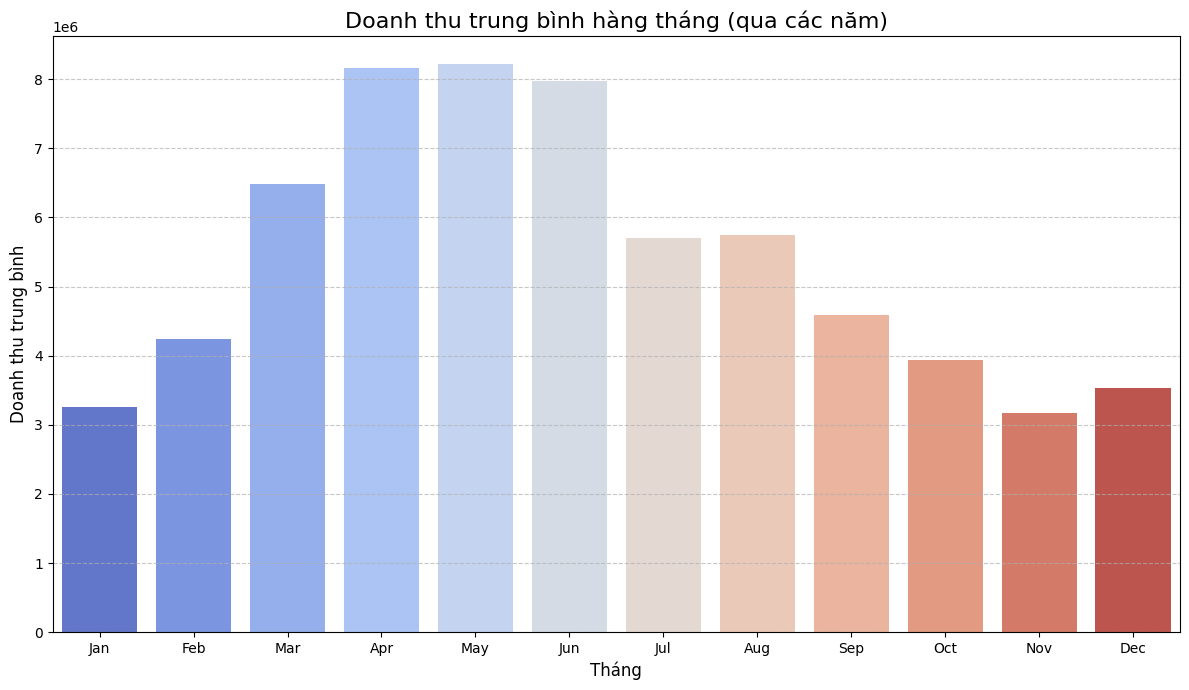

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'Date' is datetime
orders_sales['Date'] = pd.to_datetime(orders_sales['Date'])

# Extract month number (1-12)
orders_sales['Month_Num'] = orders_sales['Date'].dt.month

# Calculate the average revenue for each month across all years
average_monthly_revenue = orders_sales.groupby('Month_Num')['Revenue'].mean().reset_index()

# Map month numbers to month names for better readability on the plot
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
average_monthly_revenue['Month_Name'] = average_monthly_revenue['Month_Num'].apply(lambda x: month_names[x-1])

# Create the column chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Month_Name', y='Revenue', data=average_monthly_revenue, palette='coolwarm', hue='Month_Name', legend=False)

plt.title('Doanh thu trung bình hàng tháng (qua các năm)', fontsize=16)
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Doanh thu trung bình', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Tháng nào có trung bình lượng khách hàng qua nhiều nhất

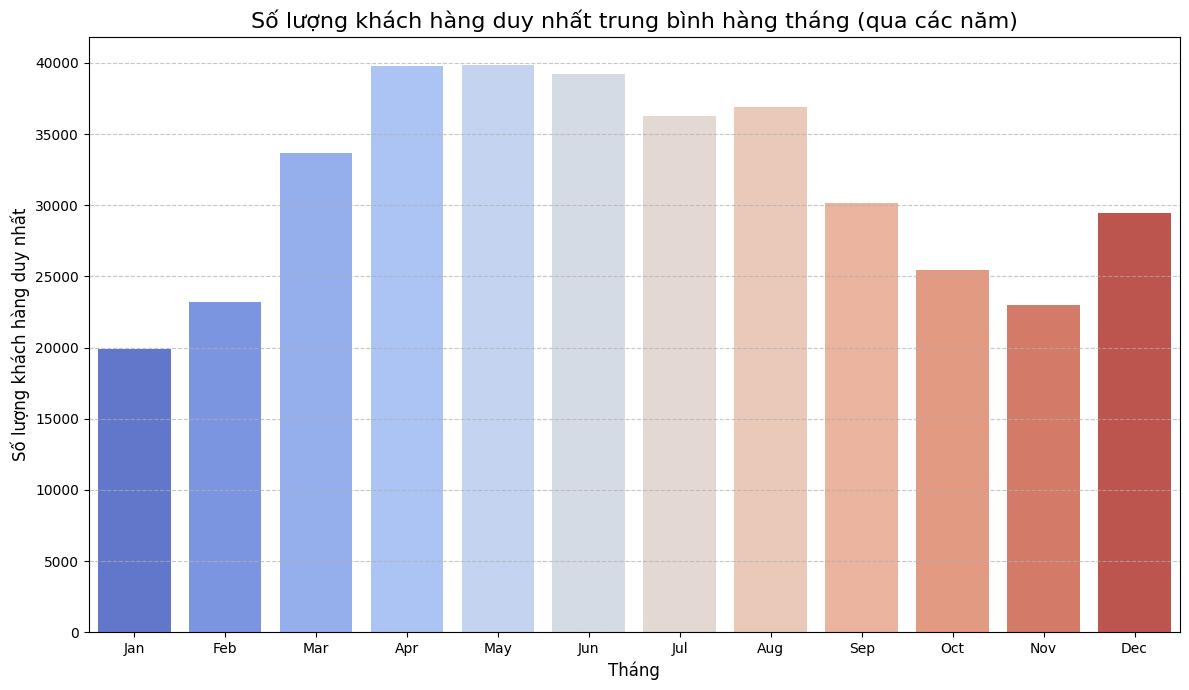

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'order_date' is datetime
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Extract month number (1-12)
orders['Month_Num'] = orders['order_date'].dt.month

# Calculate the number of unique customers for each month across all years
monthly_unique_customers = orders.groupby('Month_Num')['customer_id'].nunique().reset_index()

# Map month numbers to month names for better readability on the plot
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_unique_customers['Month_Name'] = monthly_unique_customers['Month_Num'].apply(lambda x: month_names[x-1])

# Create the column chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Month_Name', y='customer_id', data=monthly_unique_customers, palette='coolwarm', hue='Month_Name', legend=False)

plt.title('Số lượng khách hàng duy nhất trung bình hàng tháng (qua các năm)', fontsize=16)
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Số lượng khách hàng duy nhất', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Nhân khẩu học khách hàng

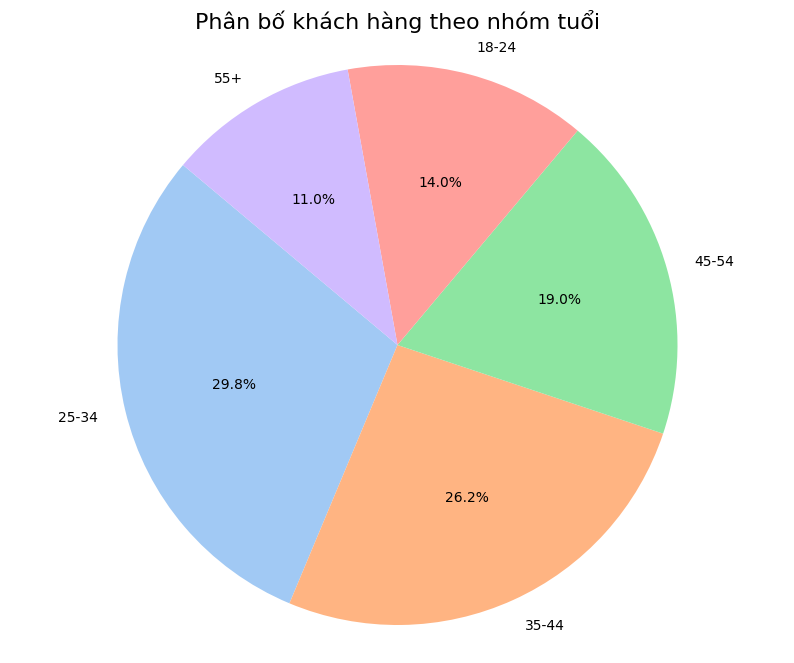

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate the count of customers in each age group
age_group_counts = customers['age_group'].value_counts().reset_index()
age_group_counts.columns = ['Age_Group', 'Customer_Count']

# Create the pie chart
plt.figure(figsize=(10, 8))
plt.pie(
    age_group_counts['Customer_Count'],
    labels=age_group_counts['Age_Group'],
    autopct='%1.1f%%', # Format percentage display
    startangle=140,    # Start the first slice at 140 degrees
    colors=sns.color_palette('pastel') # Use a nice color palette
)

plt.title('Phân bố khách hàng theo nhóm tuổi', fontsize=16)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

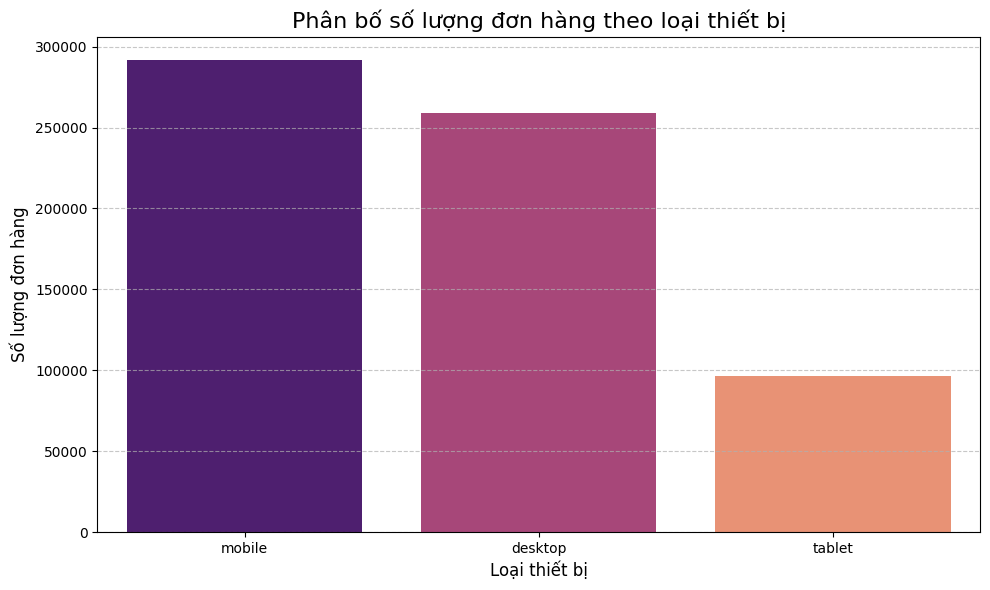

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate the count of orders for each device type
device_type_counts = orders['device_type'].value_counts().reset_index()
device_type_counts.columns = ['Device_Type', 'Order_Count']

# Sort for better visualization
device_type_counts = device_type_counts.sort_values(by='Order_Count', ascending=False)

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Device_Type', y='Order_Count', data=device_type_counts, palette='magma', hue='Device_Type', legend=False)

plt.title('Phân bố số lượng đơn hàng theo loại thiết bị', fontsize=16)
plt.xlabel('Loại thiết bị', fontsize=12)
plt.ylabel('Số lượng đơn hàng', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

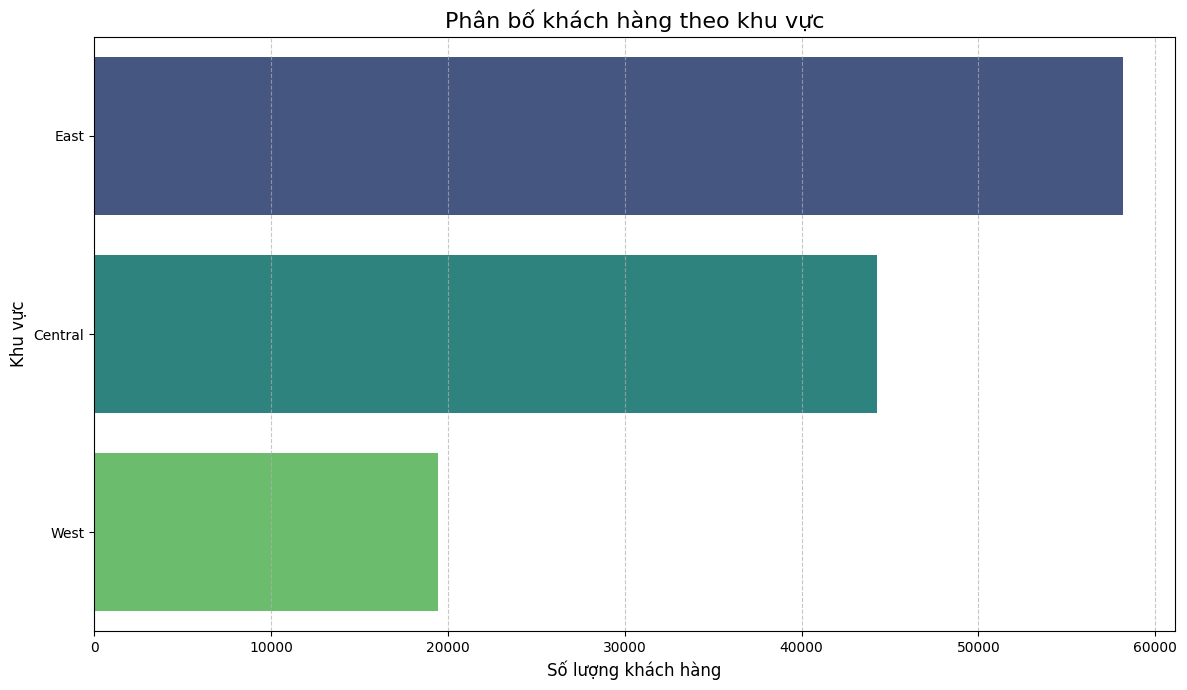

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Count the number of customers in each region from the customers_geo DataFrame
region_counts = customers_geo['region'].value_counts().reset_index()
region_counts.columns = ['Region', 'Customer_Count']

# Sort the regions by customer count for better visualization
region_counts = region_counts.sort_values(by='Customer_Count', ascending=False)

# Create the horizontal bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Customer_Count', y='Region', data=region_counts, palette='viridis', hue='Region', legend=False)

plt.title('Phân bố khách hàng theo khu vực', fontsize=16)
plt.xlabel('Số lượng khách hàng', fontsize=12)
plt.ylabel('Khu vực', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**---> Xác định Target Audience**

Sản phẩm nào có xu hướng được mua nhiều nhất

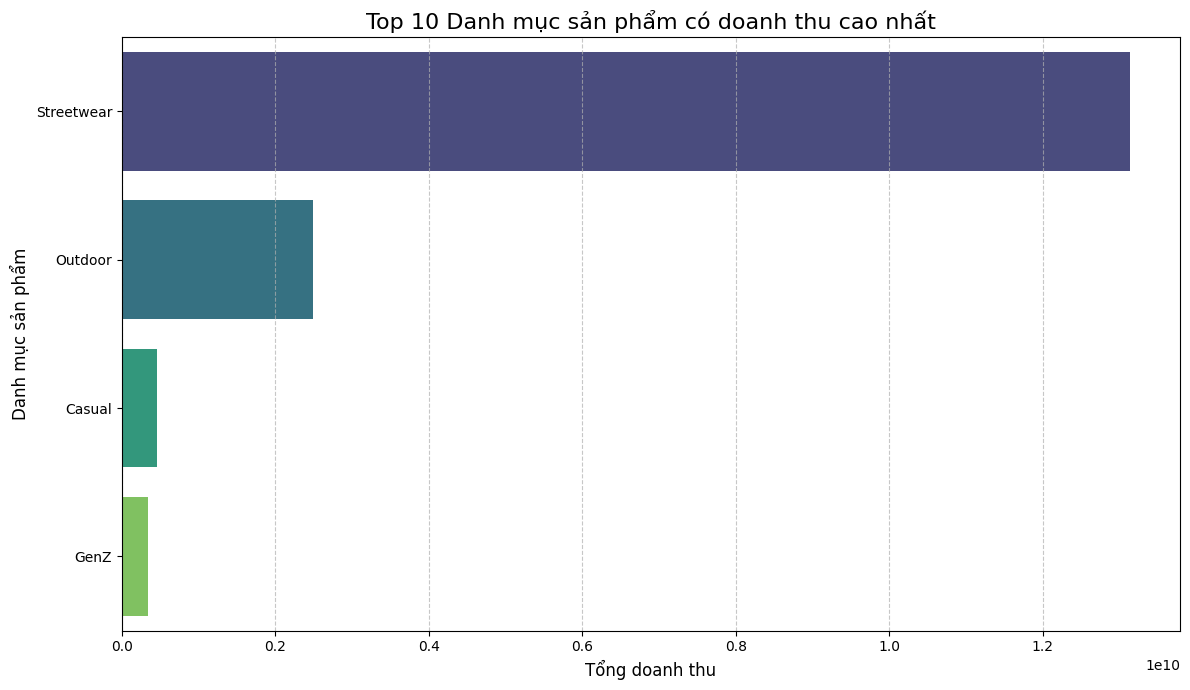

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Group by category and sum the item_revenue
category_revenue = order_detail.groupby('category')['item_revenue'].sum().reset_index()

# Sort by total revenue in descending order
category_revenue = category_revenue.sort_values(by='item_revenue', ascending=False)

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='item_revenue', y='category', data=category_revenue.head(10), palette='viridis', hue='category', legend=False)

plt.title('Top 10 Danh mục sản phẩm có doanh thu cao nhất', fontsize=16)
plt.xlabel('Tổng doanh thu', fontsize=12)
plt.ylabel('Danh mục sản phẩm', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

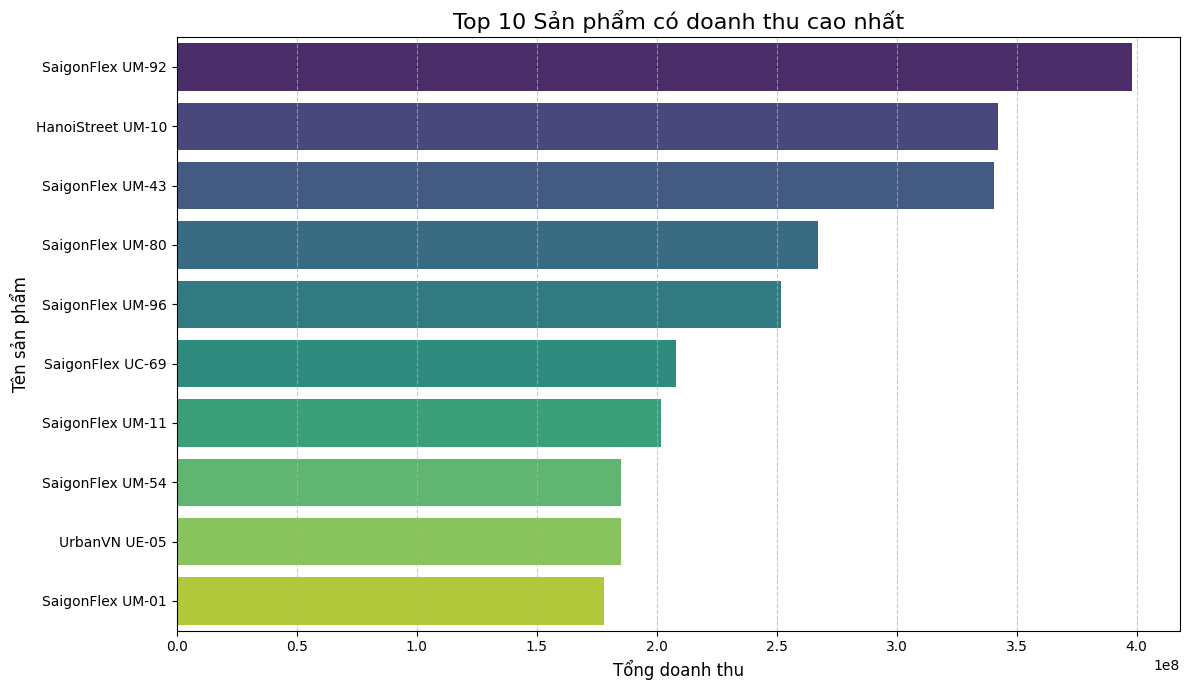

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate revenue for each item within an order
order_detail['item_revenue'] = order_detail['quantity'] * order_detail['unit_price']

# Group by product_id and product_name to get total revenue per product
product_revenue = order_detail.groupby(['product_id', 'product_name'])['item_revenue'].sum().reset_index()

# Sort by total revenue in descending order and get the top 10 products
top_10_products_by_revenue = product_revenue.sort_values(by='item_revenue', ascending=False).head(10)

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='item_revenue', y='product_name', data=top_10_products_by_revenue, palette='viridis', hue='product_name', legend=False)

plt.title('Top 10 Sản phẩm có doanh thu cao nhất', fontsize=16)
plt.xlabel('Tổng doanh thu', fontsize=12)
plt.ylabel('Tên sản phẩm', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# New Section

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate total returns per category from returns_detail
returns_by_category = returns_detail.groupby('category').size().reset_index(name='total_returned_items')

# Calculate total items sold per category from order_detail
sales_by_category = order_detail.groupby('category')['quantity'].sum().reset_index(name='total_sold_items')

# Merge the two DataFrames
category_return_analysis = returns_by_category.merge(sales_by_category, on='category', how='left')

# Calculate the return rate
category_return_analysis['return_rate'] = (category_return_analysis['total_returned_items'] / category_return_analysis['total_sold_items']) * 100

# Sort by return rate in descending order
category_return_analysis = category_return_analysis.sort_values(by='return_rate', ascending=False)

print("Phân tích tỷ lệ hoàn trả theo danh mục sản phẩm:")
display(category_return_analysis)

Phân tích tỷ lệ hoàn trả theo danh mục sản phẩm:


,category,total_returned_items,total_sold_items,return_rate
1,GenZ,2126,166848,1.274214
2,Outdoor,14720,1170000,1.258120
3,Streetwear,21799,1768826,1.232399
0,Casual,1294,107469,1.204068


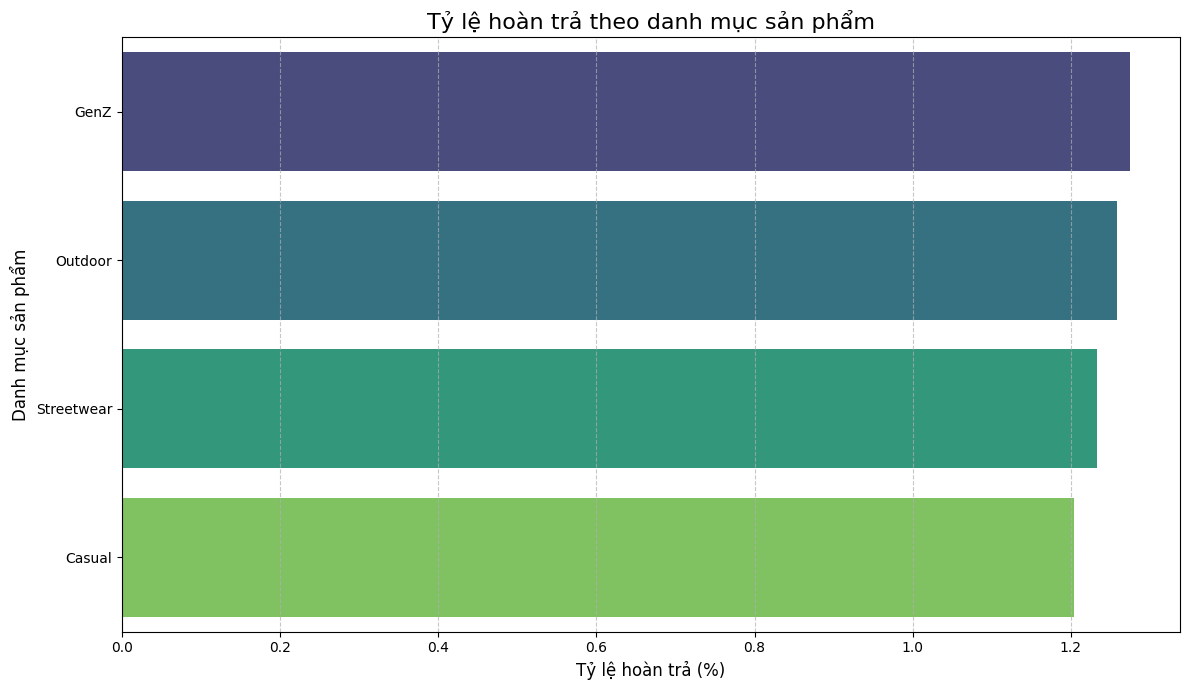

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='return_rate', y='category', data=category_return_analysis, palette='viridis', hue='category', legend=False)

plt.title('Tỷ lệ hoàn trả theo danh mục sản phẩm', fontsize=16)
plt.xlabel('Tỷ lệ hoàn trả (%)', fontsize=12)
plt.ylabel('Danh mục sản phẩm', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Merge reviews with products to get category information
reviews_with_category = reviews.merge(
    products[['product_id', 'category']],
    on='product_id',
    how='left'
)

# Calculate average rating and total reviews per category
category_review_stats = reviews_with_category.groupby('category').agg(
    avg_rating=('rating', 'mean'),
    total_reviews=('review_id', 'count')
).reset_index()

# Sort by average rating and total reviews for better visualization
category_review_stats_sorted_rating = category_review_stats.sort_values(by='avg_rating', ascending=False)
category_review_stats_sorted_reviews = category_review_stats.sort_values(by='total_reviews', ascending=False)

print("Thống kê rating và review theo danh mục sản phẩm:")
display(category_review_stats_sorted_rating)

Thống kê rating và review theo danh mục sản phẩm:


,category,avg_rating,total_reviews
3,Streetwear,3.939398,62704
2,Outdoor,3.933891,41265
0,Casual,3.923219,3790
1,GenZ,3.922825,5792


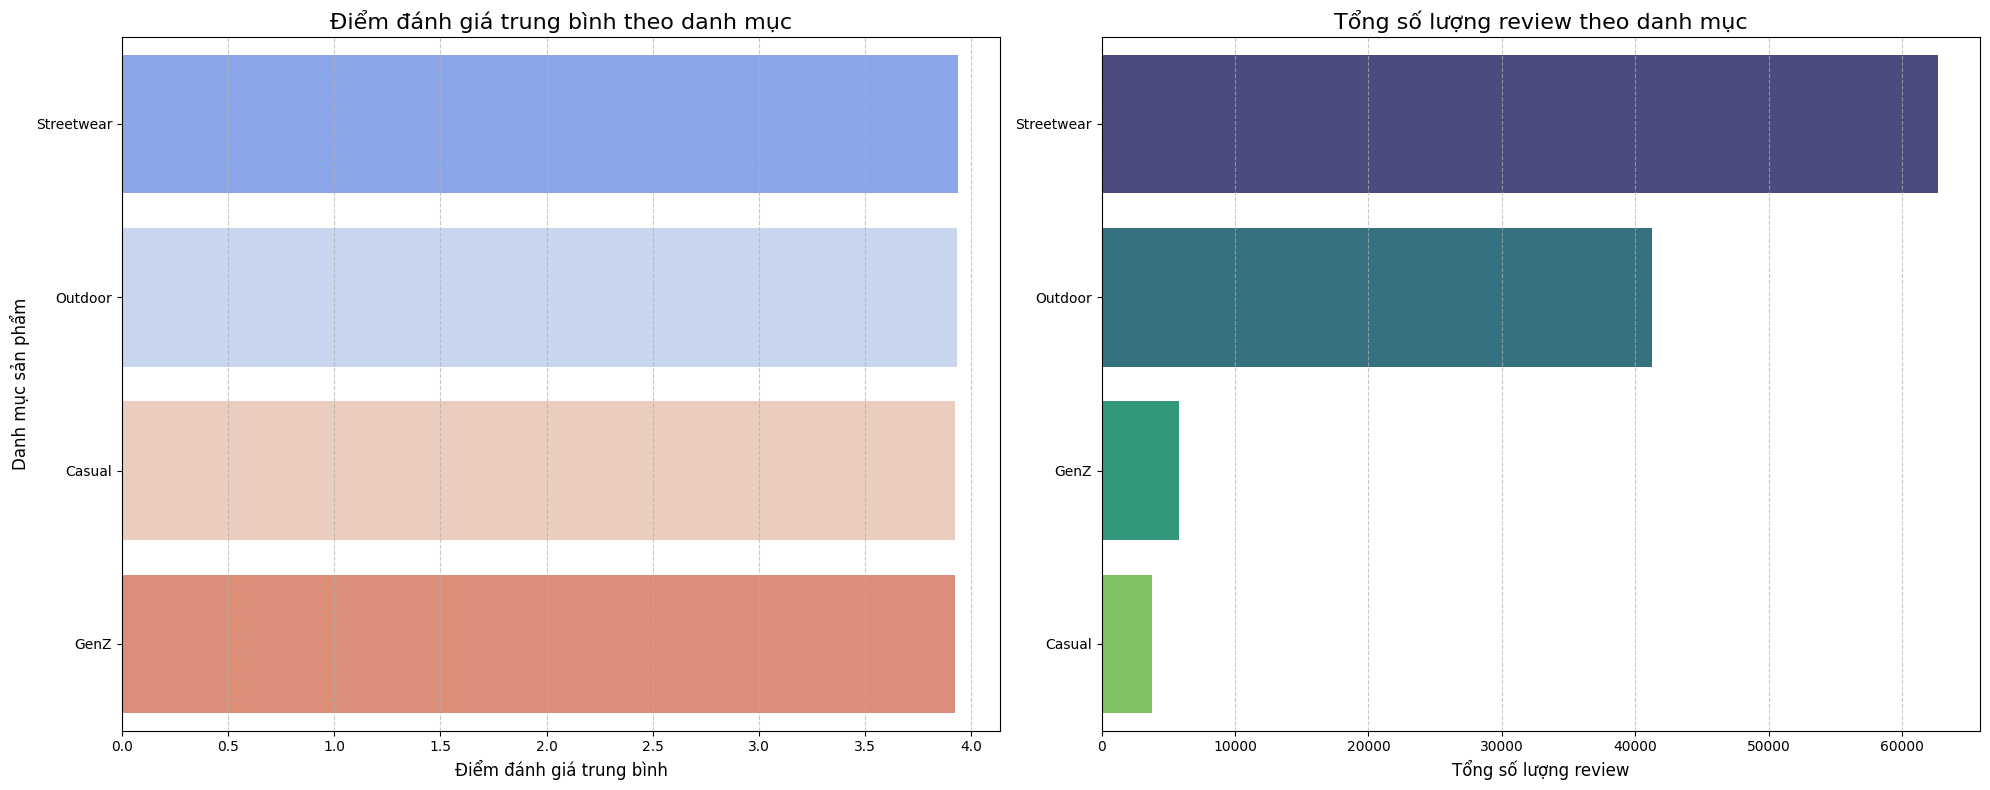

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plotting Average Rating by Category
sns.barplot(
    x='avg_rating',
    y='category',
    data=category_review_stats_sorted_rating,
    palette='coolwarm',
    hue='category',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Điểm đánh giá trung bình theo danh mục', fontsize=16)
axes[0].set_xlabel('Điểm đánh giá trung bình', fontsize=12)
axes[0].set_ylabel('Danh mục sản phẩm', fontsize=12)
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# Plotting Total Reviews by Category
sns.barplot(
    x='total_reviews',
    y='category',
    data=category_review_stats_sorted_reviews,
    palette='viridis',
    hue='category',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Tổng số lượng review theo danh mục', fontsize=16)
axes[1].set_xlabel('Tổng số lượng review', fontsize=12)
axes[1].set_ylabel('', fontsize=12) # No y-label for the second plot as it's the same
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Tháng nào có chiết khấu được sử dụng nhiều nhất ?

Traffic

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calculate the number of unique orders for each order source
# using the 'orders' DataFrame, as it contains 'order_source' directly.
# This reflects the number of 'conversions' (orders) attributed to each source.
orders_by_source = orders.groupby('order_source')['order_id'].nunique().reset_index()
orders_by_source.columns = ['Order_Source', 'Number_of_Orders']

# Sort by the number of orders in descending order
orders_by_source = orders_by_source.sort_values(by='Number_of_Orders', ascending=False)

print("Số lượng đơn hàng theo nguồn:")
display(orders_by_source)

Số lượng đơn hàng theo nguồn:


,Order_Source,Number_of_Orders
2,organic_search,181495
3,paid_search,141652
5,social_media,129710
1,email_campaign,77572
4,referral,64565
0,direct,51951


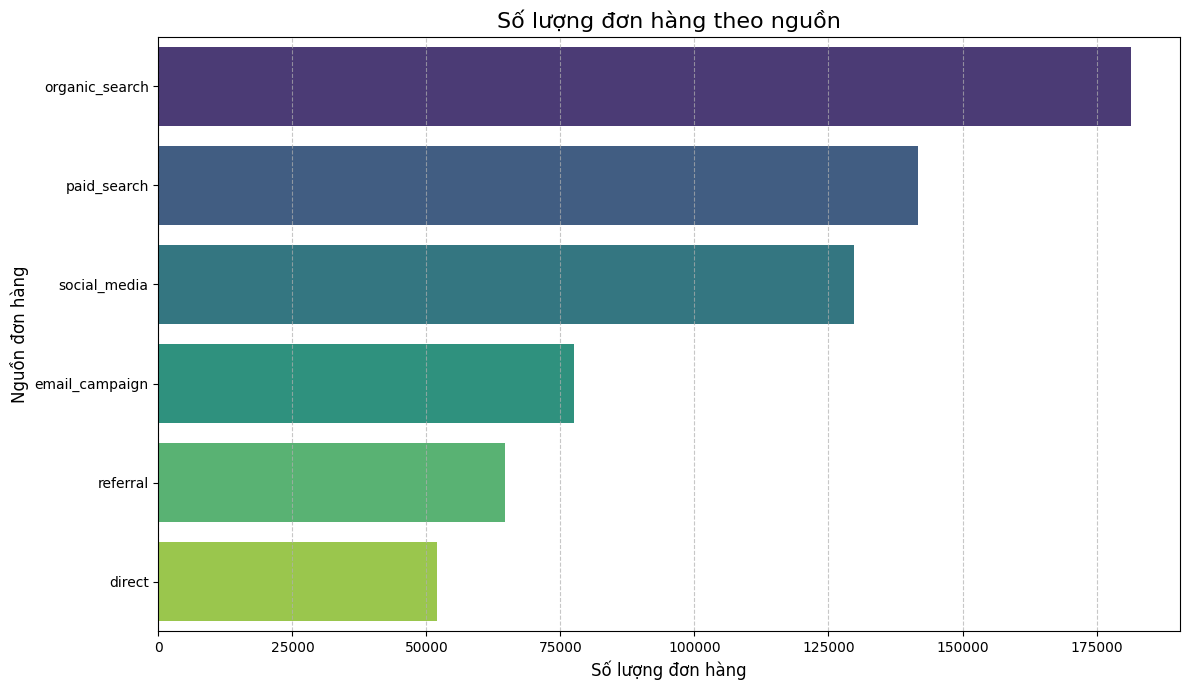

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Number_of_Orders', y='Order_Source', data=orders_by_source, palette='viridis', hue='Order_Source', legend=False)

plt.title('Số lượng đơn hàng theo nguồn', fontsize=16)
plt.xlabel('Số lượng đơn hàng', fontsize=12)
plt.ylabel('Nguồn đơn hàng', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Group by order_source and sum the Revenue
revenue_by_source = orders_sales.groupby('order_source')['Revenue'].sum().reset_index()

# Sort by total revenue in descending order
revenue_by_source = revenue_by_source.sort_values(by='Revenue', ascending=False)

print("Doanh thu theo nguồn đơn hàng:")
display(revenue_by_source)

Doanh thu theo nguồn đơn hàng:


,order_source,Revenue
2,organic_search,1.072707e+12
3,paid_search,8.337475e+11
5,social_media,7.645988e+11
1,email_campaign,4.580059e+11
4,referral,3.814258e+11
0,direct,3.081907e+11


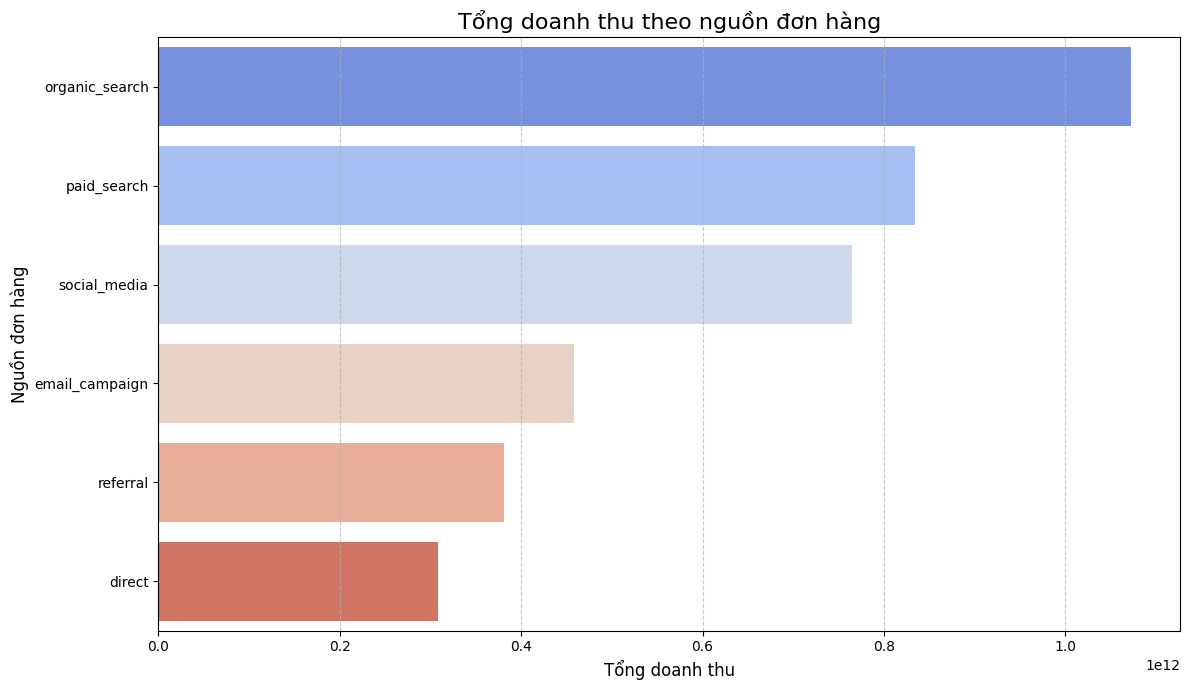

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Revenue', y='order_source', data=revenue_by_source, palette='coolwarm', hue='order_source', legend=False)

plt.title('Tổng doanh thu theo nguồn đơn hàng', fontsize=16)
plt.xlabel('Tổng doanh thu', fontsize=12)
plt.ylabel('Nguồn đơn hàng', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Count the occurrences of each return reason
return_reason_counts = returns_detail['return_reason'].value_counts().reset_index()
return_reason_counts.columns = ['Return_Reason', 'Count']

# Sort by count in descending order
return_reason_counts = return_reason_counts.sort_values(by='Count', ascending=False)

print("Các lý do trả hàng phổ biến nhất:")
display(return_reason_counts)

Các lý do trả hàng phổ biến nhất:


,Return_Reason,Count
0,wrong_size,13967
1,defective,8020
2,not_as_described,7035
3,changed_mind,6931
4,late_delivery,3986


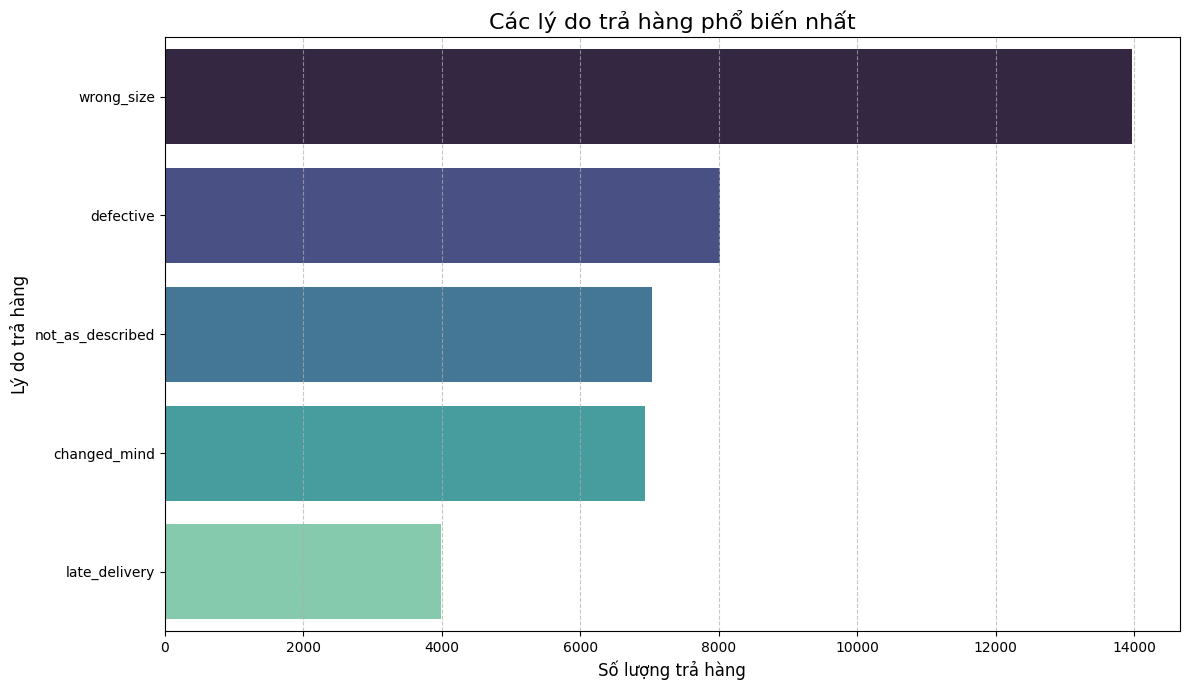

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='Count', y='Return_Reason', data=return_reason_counts, palette='mako', hue='Return_Reason', legend=False)

plt.title('Các lý do trả hàng phổ biến nhất', fontsize=16)
plt.xlabel('Số lượng trả hàng', fontsize=12)
plt.ylabel('Lý do trả hàng', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()